In [1]:
!pip install timm
!pip install Pillow
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu128



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install --no-cache-dir --force-reinstall torch==2.11.0+cu128 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 47.9 MB/s eta 0:00:58
   ---------------------------------------- 0.0/2.8 GB 29.0 MB/s eta 0:01:36
   ---------------------------------------- 0.0/2.8 GB 24.1 MB/s eta 0:01:55
   ---------------------------------------- 0.0/2.8 GB 20.9 MB/s eta 0:02:12
   ---------------------------------------- 0.0/2.8 GB 19.0 MB/s eta 0:02:25
   ---------------------------------------- 0.0/2.8 GB 17.9 MB/s eta 0:02:34
   ---------------------------------------- 0.0/2.8 GB 17.1 MB/s eta 0:02:41
   ---------------------------------------- 0.0/2.8 GB 16.3 MB/s eta 0:02:49
   ---------------------------------------- 0.0/2.8 GB 16.0 MB/s eta 0:02:52
   ---------------------------------------- 0.0/2.8 GB 15.5 MB/s eta 0:02:57
   ---------------------------------------- 0.0/2.8 GB 15.3 MB/s eta 0:03:00
    ---------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from timm.models.vision_transformer import VisionTransformer
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


c:\Users\Raamprasanth Ramesh\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
## 1. Data Loading and Preparation
class KidneyCTDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for cls in self.classes:
            cls_dir = os.path.join(self.root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for img_name in os.listdir(cls_dir):
                if img_name.endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(cls_dir, img_name)
                    samples.append((img_path, self.class_to_idx[cls]))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, torch.tensor(label, dtype=torch.long)

In [4]:
# Data transformations with augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [23]:
# Load dataset
dataset = KidneyCTDataset(root_dir="C:/Users/Raamprasanth Ramesh/Downloads/dataset/Data")


In [24]:
# Split dataset
train_idx, val_idx = train_test_split(
    np.arange(len(dataset)), 
    test_size=0.2, 
    stratify=[sample[1] for sample in dataset.samples],
    random_state=42
)

In [25]:
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

In [26]:
# Apply transforms
train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']


In [27]:
# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


# Hybrid ConvNeXt-Vision Transformer (ViT) for Kidney CT Classification

In [28]:
import torch
import torch.nn as nn
from timm.models.vision_transformer import VisionTransformer

class ConvNeXtBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)  # depthwise conv
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)  # pointwise/1x1 convs
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        
    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)  # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        x = x.permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
        
        x = input + x
        return x

class HybridConvNeXtViT(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        # ConvNeXt Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=2, padding=3),
            nn.LayerNorm([96, 112, 112], eps=1e-6)
        )
        
        # ConvNeXt Blocks
        self.convnext_blocks = nn.Sequential(
            *[ConvNeXtBlock(96) for _ in range(3)]
        )
        
        # Patch Embedding for ViT
        self.patch_embed = nn.Conv2d(96, 768, kernel_size=16, stride=16)
        
        # Initialize a dummy tensor to get the number of patches
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            dummy_out = self.patch_embed(self.convnext_blocks(self.stem(dummy_input)))
            num_patches = dummy_out.shape[2] * dummy_out.shape[3]
        
        # Vision Transformer
        self.vit = VisionTransformer(
            img_size=224,  # Original image size
            patch_size=16,  # Should match our patch embed stride
            in_chans=768,
            embed_dim=768,
            depth=12,
            num_heads=12,
            mlp_ratio=4,
            qkv_bias=True,
            num_classes=num_classes  # Direct classification
        )
        
        # Remove the default patch embed and proj from ViT since we have our own
        del self.vit.patch_embed
        del self.vit.head
        
        # Positional embedding needs to be adjusted for our patch count
        self.vit.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, 768),
            requires_grad=True
        )
        nn.init.trunc_normal_(self.vit.pos_embed, std=0.02)
        
    def forward(self, x):
        # ConvNeXt path
        x = self.stem(x)
        x = self.convnext_blocks(x)
        
        # Create patches for ViT
        x = self.patch_embed(x)  # (B, 768, H', W')
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, H'*W', C)
        
        # Add class token
        cls_token = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        
        # Add positional embedding
        x = x + self.vit.pos_embed
        
        # ViT processing
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        
        # Classifier "token" (first token)
        x = x[:, 0]
        
        return x

# Reinitialize the model with fixed architecture
model = HybridConvNeXtViT(num_classes=4).to(device)

In [29]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [30]:
# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

In [ ]:
from tqdm import tqdm
import time

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                desc = 'Training'
            else:
                model.eval()
                dataloader = val_loader
                desc = 'Validating'
                
            running_loss = 0.0
            running_corrects = 0
            
            # Initialize tqdm progress bar
            batch_bar = tqdm(total=len(dataloader), desc=desc, position=0, leave=False)
            
            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Update progress bar
                batch_bar.set_postfix(
                    loss=f"{running_loss/(batch_bar.n+1):.4f}",
                    acc=f"{running_corrects.double()/((batch_bar.n+1)*batch_size):.4f}"
                )
                batch_bar.update(1)
                
            # Close progress bar
            batch_bar.close()
            
            if phase == 'train':
                scheduler.step()
                
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'best_model.pth')
                print("Saved best model!")
                
        print()
    
    print(f'Best val Acc: {best_acc:4f}')
    return model

# Train the model with tqdm progress bars
model = train_model(model, criterion, optimizer, scheduler, num_epochs=5)

Epoch 1/5
----------


Training:   0%|          | 0/312 [00:00<?, ?it/s]

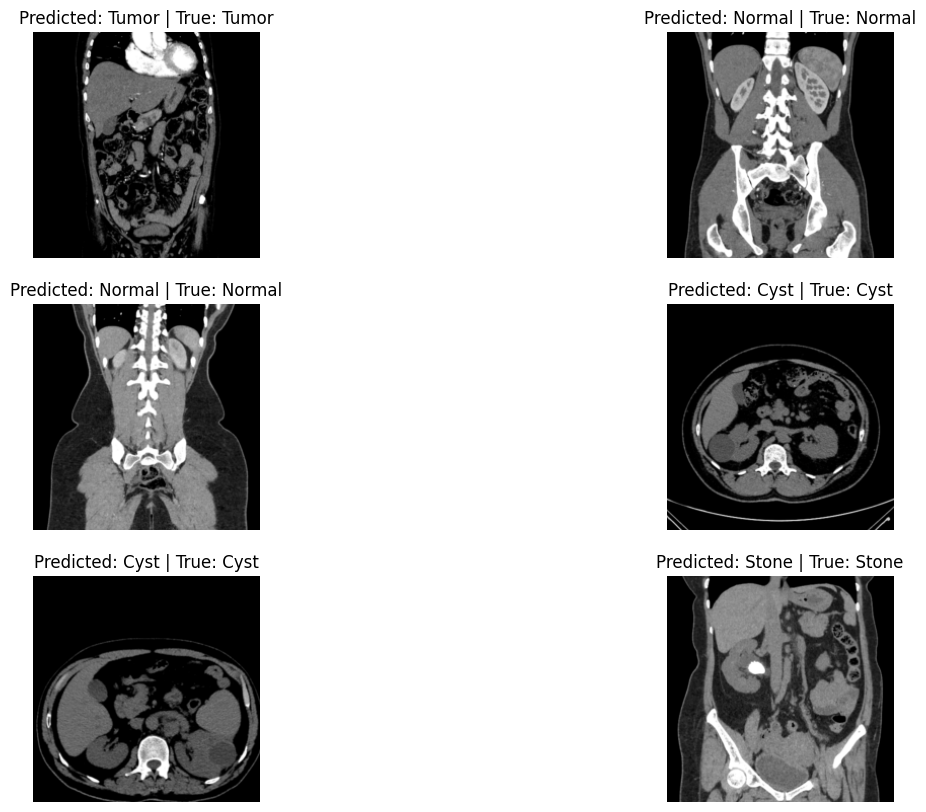

In [ ]:
## 5. Evaluation and Visualization
def visualize_predictions(model, dataloader, num_images=6):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {dataset.classes[preds[j]]} | True: {dataset.classes[labels[j]]}')
                
                # Inverse normalization for visualization
                inv_normalize = transforms.Normalize(
                    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                    std=[1/0.229, 1/0.224, 1/0.225]
                )
                img = inv_normalize(inputs.cpu().data[j]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
                ax.imshow(img)
                
                if images_so_far == num_images:
                    return

# Visualize some predictions
visualize_predictions(model, val_loader)

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
}, 'full_model.pth')

Evaluating: 100%|██████████| 78/78 [00:13<00:00,  5.90it/s]


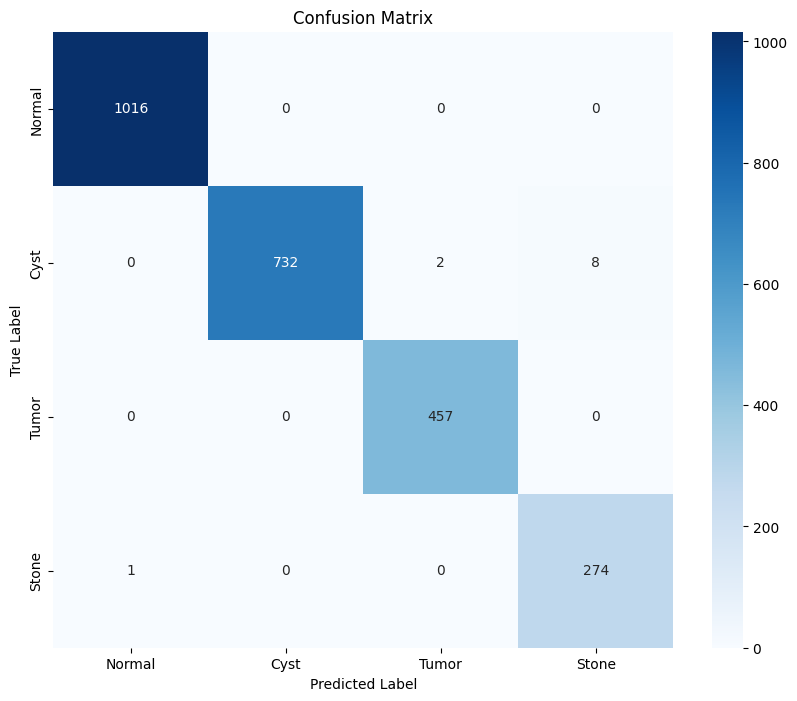


Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| Normal       |    0.999017 | 1        |   0.999508 | 1016        |
| Cyst         |    1        | 0.986523 |   0.993216 |  742        |
| Tumor        |    0.995643 | 1        |   0.997817 |  457        |
| Stone        |    0.971631 | 0.996364 |   0.983842 |  275        |
| accuracy     |    0.995582 | 0.995582 |   0.995582 |    0.995582 |
| macro avg    |    0.991573 | 0.995722 |   0.993596 | 2490        |
| weighted avg |    0.995666 | 0.995582 |   0.995592 | 2490        |


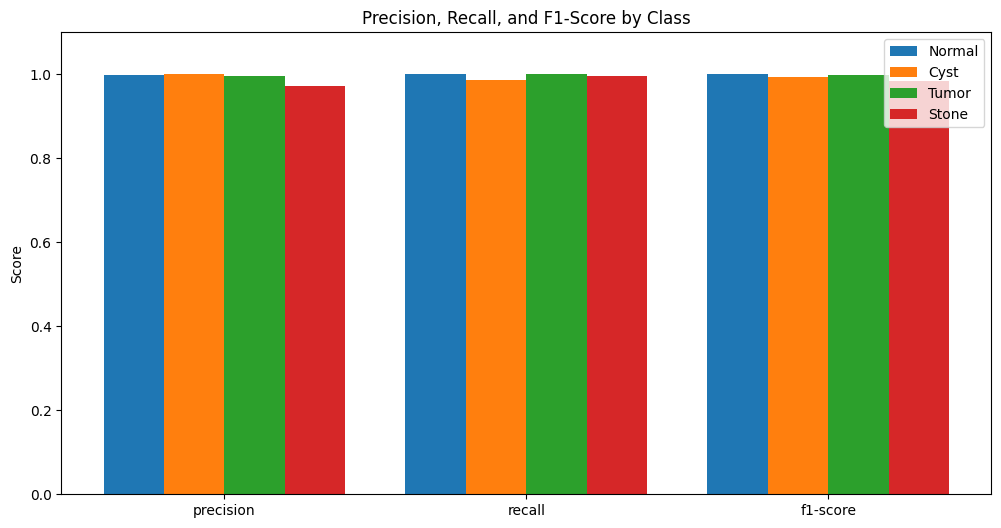

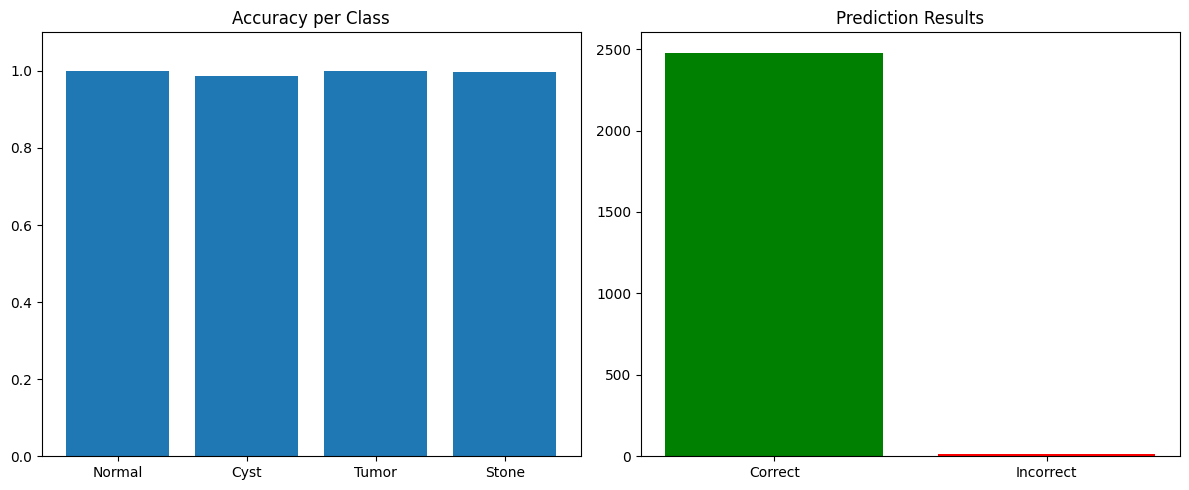

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions
true_labels, pred_labels = evaluate_model(model, val_loader)

# 1. Confusion Matrix
def plot_confusion_matrix(true_labels, pred_labels, classes):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(true_labels, pred_labels, dataset.classes)

# 2. Classification Report
def print_classification_report(true_labels, pred_labels, classes):
    report = classification_report(true_labels, pred_labels, target_names=classes, output_dict=True)
    df = pd.DataFrame(report).transpose()
    print("\nClassification Report:")
    print(df.to_markdown())
    
    # Plot precision-recall for each class
    metrics = ['precision', 'recall', 'f1-score']
    plt.figure(figsize=(12, 6))
    for i, cls in enumerate(classes):
        values = [report[cls][m] for m in metrics]
        plt.bar(np.arange(len(metrics)) + i*0.2, values, width=0.2, label=cls)
    
    plt.xticks(np.arange(len(metrics)) + 0.3, metrics)
    plt.title('Precision, Recall, and F1-Score by Class')
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.show()

print_classification_report(true_labels, pred_labels, dataset.classes)

# 3. Additional Metrics Visualization
def plot_metrics(true_labels, pred_labels):
    # Calculate per-class accuracy
    cm = confusion_matrix(true_labels, pred_labels)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy per class
    plt.subplot(1, 2, 1)
    plt.bar(dataset.classes, class_acc)
    plt.title('Accuracy per Class')
    plt.ylim(0, 1.1)
    
    # Plot error types
    plt.subplot(1, 2, 2)
    error_types = ['Correct', 'Incorrect']
    error_counts = [sum(np.array(true_labels) == np.array(pred_labels)), 
                   sum(np.array(true_labels) != np.array(pred_labels))]
    plt.bar(error_types, error_counts, color=['green', 'red'])
    plt.title('Prediction Results')
    
    plt.tight_layout()
    plt.show()

plot_metrics(true_labels, pred_labels)

Predicted Class: Normal
Confidence Score: 1.0000


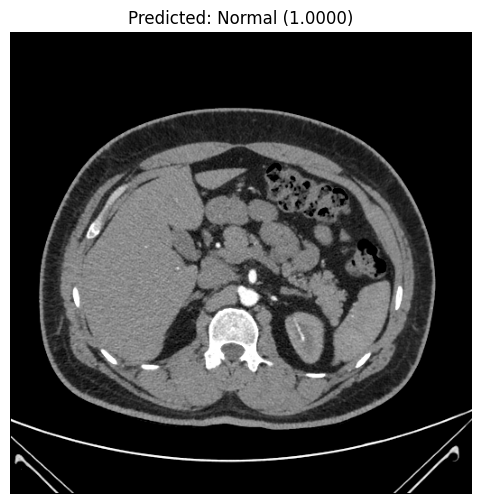

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
from timm.models.vision_transformer import VisionTransformer

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the ConvNeXtBlock class (same as in the original code)
class ConvNeXtBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)  # depthwise conv
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)  # pointwise/1x1 convs
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        
    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)  # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        x = x.permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
        x = input + x
        return x

# Define the HybridConvNeXtViT class (same as in the original code)
class HybridConvNeXtViT(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        # ConvNeXt Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=2, padding=3),
            nn.LayerNorm([96, 112, 112], eps=1e-6)
        )
        
        # ConvNeXt Blocks
        self.convnext_blocks = nn.Sequential(
            *[ConvNeXtBlock(96) for _ in range(3)]
        )
        
        # Patch Embedding for ViT
        self.patch_embed = nn.Conv2d(96, 768, kernel_size=16, stride=16)
        
        # Initialize a dummy tensor to get the number of patches
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            dummy_out = self.patch_embed(self.convnext_blocks(self.stem(dummy_input)))
            num_patches = dummy_out.shape[2] * dummy_out.shape[3]
        
        # Vision Transformer
        self.vit = VisionTransformer(
            img_size=224,  # Original image size
            patch_size=16,  # Should match our patch embed stride
            in_chans=768,
            embed_dim=768,
            depth=12,
            num_heads=12,
            mlp_ratio=4,
            qkv_bias=True,
            num_classes=num_classes  # Direct classification
        )
        
        # Remove the default patch embed and proj from ViT since we have our own
        del self.vit.patch_embed
        del self.vit.head
        
        # Positional embedding needs to be adjusted for our patch count
        self.vit.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, 768),
            requires_grad=True
        )
        nn.init.trunc_normal_(self.vit.pos_embed, std=0.02)
        
    def forward(self, x):
        # ConvNeXt path
        x = self.stem(x)
        x = self.convnext_blocks(x)
        
        # Create patches for ViT
        x = self.patch_embed(x)  # (B, 768, H', W')
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, H'*W', C)
        
        # Add class token
        cls_token = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        
        # Add positional embedding
        x = x + self.vit.pos_embed
        
        # ViT processing
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        
        # Classifier "token" (first token)
        x = x[:, 0]
        
        return x

# Define the data transformation (same as 'val' transform in original code)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the model
model = HybridConvNeXtViT(num_classes=4).to(device)
checkpoint = torch.load('full_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Define class names
classes = ['Normal', 'Cyst', 'Tumor', 'Stone']

# Function to predict on a single image
def predict_single_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = val_transform(image)
    image = image.unsqueeze(0).to(device)  # Add batch dimension
    
    # Make prediction
    with torch.no_grad():
        output = model(image)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
        predicted_class = classes[predicted.item()]
        confidence_score = confidence.item()
    
    return predicted_class, confidence_score

# Example usage
image_path = r'dataset\Data\Normal\Normal- (4).jpg'  # Replace with the path to your image
predicted_class, confidence_score = predict_single_image(image_path)
print(f'Predicted Class: {predicted_class}')
print(f'Confidence Score: {confidence_score:.4f}')

# Optional: Visualize the image and prediction
import matplotlib.pyplot as plt

def visualize_single_prediction(image_path, predicted_class, confidence_score):
    image = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f'Predicted: {predicted_class} ({confidence_score:.4f})')
    plt.axis('off')
    plt.show()

visualize_single_prediction(image_path, predicted_class, confidence_score)

# 3D Convolution on Multi-Slice CT with Transformer 

In [ ]:
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
## 1. Complete Data Loading
class KidneyCT3DDataset(Dataset):
    def __init__(self, root_dir, num_slices=16, transform=None, overlap=8):
        self.root_dir = root_dir
        self.num_slices = num_slices
        self.transform = transform
        self.overlap = overlap  # Controls overlap between volumes
        self.classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = self._load_all_data()
        
        if len(self.samples) == 0:
            found_classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
            raise ValueError(f"No CT volumes created. Found classes: {found_classes}. Check slice numbers per class.")
            
    def _load_all_data(self):
        samples = []
        for cls in self.classes:
            cls_dir = os.path.join(self.root_dir, cls)
            if not os.path.isdir(cls_dir):
                print(f"Warning: Class directory {cls_dir} not found")
                continue
                
            # Load all slices for this class
            slices = sorted(
                [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
                key=lambda x: int(re.search(r'\d+', x).group())  # Sort by slice number
            )
            
            # Create all possible volumes with overlap
            for i in range(0, len(slices) - self.num_slices + 1, self.num_slices - self.overlap):
                slice_paths = [os.path.join(cls_dir, slices[i+j]) for j in range(self.num_slices)]
                samples.append((slice_paths, self.class_to_idx[cls]))
                
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        slice_paths, label = self.samples[idx]
        volume = []
        
        for path in slice_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            volume.append(img)
            
        # Stack to create (C, D, H, W) volume
        volume = torch.stack(volume, dim=1)
        return volume, torch.tensor(label, dtype=torch.long)

In [ ]:
# Modified Data Loading to Use All Images
class KidneyCT3DDataset(Dataset):
    def __init__(self, root_dir, num_slices=16, transform=None, overlap=15):
        """
        overlap=15 means we only shift by 1 slice each time (16-15=1)
        This creates maximum number of volumes while maintaining context
        """
        self.root_dir = root_dir
        self.num_slices = num_slices
        self.transform = transform
        self.overlap = overlap
        self.classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = self._load_all_data()
        
        print(f"\nClass Distribution:")
        for cls in self.classes:
            cls_count = sum(1 for _, label in self.samples if label == self.class_to_idx[cls])
            total_slices = len([f for f in os.listdir(os.path.join(root_dir, cls)) 
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"{cls}: {cls_count} volumes (from {total_slices} slices)")
            
    def _load_all_data(self):
        samples = []
        for cls in self.classes:
            cls_dir = os.path.join(self.root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
                
            slices = sorted(
                [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
                key=lambda x: int(re.search(r'\d+', x).group())
            )
            
            # Create maximum number of volumes with 1-slice stride
            for i in range(0, len(slices) - self.num_slices + 1, self.num_slices - self.overlap):
                slice_paths = [os.path.join(cls_dir, slices[i+j]) for j in range(self.num_slices)]
                samples.append((slice_paths, self.class_to_idx[cls]))
                
        return samples

# Initialize dataset with maximum overlap
full_dataset = KidneyCT3DDataset(
    root_dir="C:/Users/Raamprasanth Ramesh/Downloads/dataset/Data",
    num_slices=16,
    overlap=15,  # Only shift by 1 slice between volumes
    transform=data_transforms['train']
)




Class Distribution:
Normal: 5062 volumes (from 5077 slices)
Cyst: 3694 volumes (from 3709 slices)
Tumor: 2268 volumes (from 2283 slices)
Stone: 1362 volumes (from 1377 slices)



Class Distribution:
Normal: 5062 volumes (from 5077 slices)
Cyst: 3694 volumes (from 3709 slices)
Tumor: 2268 volumes (from 2283 slices)
Stone: 1362 volumes (from 1377 slices)
Volume shape: torch.Size([3, 16, 224, 224])


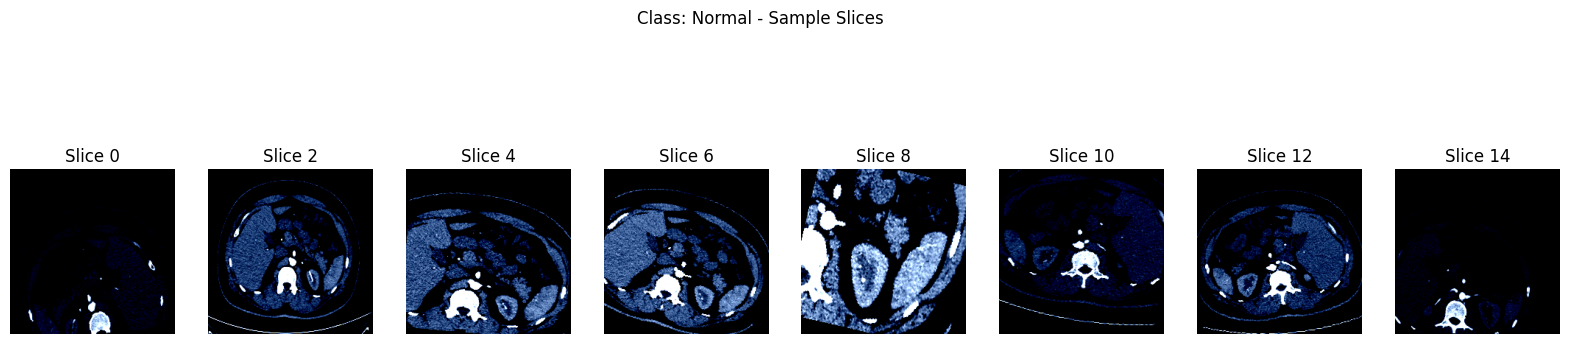

In [ ]:
class KidneyCT3DDataset(Dataset):
    def __init__(self, root_dir, num_slices=16, transform=None, overlap=15):
        self.root_dir = root_dir
        self.num_slices = num_slices
        self.transform = transform
        self.overlap = overlap
        self.classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = self._load_all_data()
        
        print(f"\nClass Distribution:")
        for cls in self.classes:
            cls_count = sum(1 for _, label in self.samples if label == self.class_to_idx[cls])
            total_slices = len([f for f in os.listdir(os.path.join(root_dir, cls)) 
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"{cls}: {cls_count} volumes (from {total_slices} slices)")
            
    def _load_all_data(self):
        samples = []
        for cls in self.classes:
            cls_dir = os.path.join(self.root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
                
            slices = sorted(
                [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
                key=lambda x: int(re.search(r'\d+', x).group())
            )
            
            for i in range(0, len(slices) - self.num_slices + 1, self.num_slices - self.overlap):
                slice_paths = [os.path.join(cls_dir, slices[i+j]) for j in range(self.num_slices)]
                samples.append((slice_paths, self.class_to_idx[cls]))
                
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        slice_paths, label = self.samples[idx]
        volume = []
        
        for path in slice_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            volume.append(img)
            
        # Stack to create (C, D, H, W) volume
        volume = torch.stack(volume, dim=1)
        return volume, torch.tensor(label, dtype=torch.long)

# Now initialize the dataset
full_dataset = KidneyCT3DDataset(
    root_dir="C:/Users/Raamprasanth Ramesh/Downloads/dataset/Data",
    num_slices=16,
    overlap=15,
    transform=data_transforms['train']
)

# Test visualization
sample_volume, label = full_dataset[0]
print(f"Volume shape: {sample_volume.shape}")  # Should be (3, 16, 224, 224)

# Visualize slices
def visualize_slices(volume, num_slices=8):
    volume = volume.permute(1, 2, 3, 0)  # (D, H, W, C)
    step = volume.shape[0] // num_slices
    fig, axes = plt.subplots(1, num_slices, figsize=(20, 5))
    
    for i, ax in enumerate(axes):
        slice_idx = i * step
        ax.imshow(volume[slice_idx].cpu().numpy())
        ax.set_title(f"Slice {slice_idx}")
        ax.axis('off')
    plt.suptitle(f"Class: {full_dataset.classes[label]} - Sample Slices")
    plt.show()

visualize_slices(sample_volume)

In [ ]:
## 3. Train-Val Split (Stratified)
labels = [sample[1] for sample in full_dataset.samples]
train_idx, val_idx = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
val_dataset = torch.utils.data.Subset(full_dataset, val_idx)
val_dataset.dataset.transform = data_transforms['val']

In [ ]:
# Create dataloaders
batch_size = 8  # Reduced for 3D volumes
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


In [ ]:
## 4. Enhanced 3D Model
class CT3DTransformer(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        # 3D CNN backbone
        self.cnn_3d = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),
            
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),
            
            nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),
        )
        
        # Transformer
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=256,
                nhead=8,
                dim_feedforward=1024,
                dropout=0.1
            ),
            num_layers=6
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x shape: (B, C, D, H, W)
        B = x.shape[0]
        
        # 3D CNN
        x = self.cnn_3d(x)  # (B, 256, D', H', W')
        
        # Prepare for transformer
        x = x.permute(0, 2, 3, 4, 1)  # (B, D', H', W', C)
        x = x.reshape(B, -1, 256)      # (B, N, 256)
        
        # Transformer
        x = self.transformer(x)
        
        # Global average pooling
        x = x.mean(dim=1)
        
        # Classify
        return self.classifier(x)

model = CT3DTransformer(num_classes=4).to(device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
## 5. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

In [ ]:
## 6. Complete Training Loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25):
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            
            # Initialize progress bar
            batch_bar = tqdm(enumerate(dataloader), total=len(dataloader), 
                            desc=f"{phase.capitalize()} Epoch {epoch+1}")
            
            for i, (inputs, labels) in batch_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Update statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Update progress bar
                batch_bar.set_postfix(
                    loss=f"{running_loss/((i+1)*inputs.size(0)):.4f}",
                    acc=f"{running_corrects.double()/((i+1)*inputs.size(0)):.4f}"
                )
            
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Save best model and adjust learning rate
            if phase == 'val':
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), 'best_3d_ct_model.pth')
                    print("Saved best model!")
    
    print(f'Best val Acc: {best_acc:.4f}')
    return model

# Train the model
model = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25)

Epoch 1/25
----------


Train Epoch 1: 100%|██████████| 1239/1239 [18:26<00:00,  1.12it/s, acc=1.3234, loss=1.7959]

train Loss: 0.8983 Acc: 0.6620



Val Epoch 1: 100%|██████████| 310/310 [02:28<00:00,  2.09it/s, acc=0.9710, loss=0.9769]

val Loss: 0.7333 Acc: 0.7288
Saved best model!
Epoch 2/25
----------


...

val Loss: 0.0134 Acc: 0.9952
Epoch 25/25
----------



Train Epoch 25: 100%|██████████| 1239/1239 [18:26<00:00,  1.12it/s, acc=1.9820, loss=0.0508]

train Loss: 0.0254 Acc: 0.9914



Val Epoch 25: 100%|██████████| 310/310 [02:35<00:00,  1.99it/s, acc=1.3242, loss=0.0213]

val Loss: 0.0160 Acc: 0.9939
Best val Acc: 0.9956


In [ ]:
## 7. Complete Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Generate predictions
true_labels, pred_labels = evaluate_model(model, val_loader)

Evaluating: 100%|██████████| 310/310 [02:30<00:00,  2.06it/s]


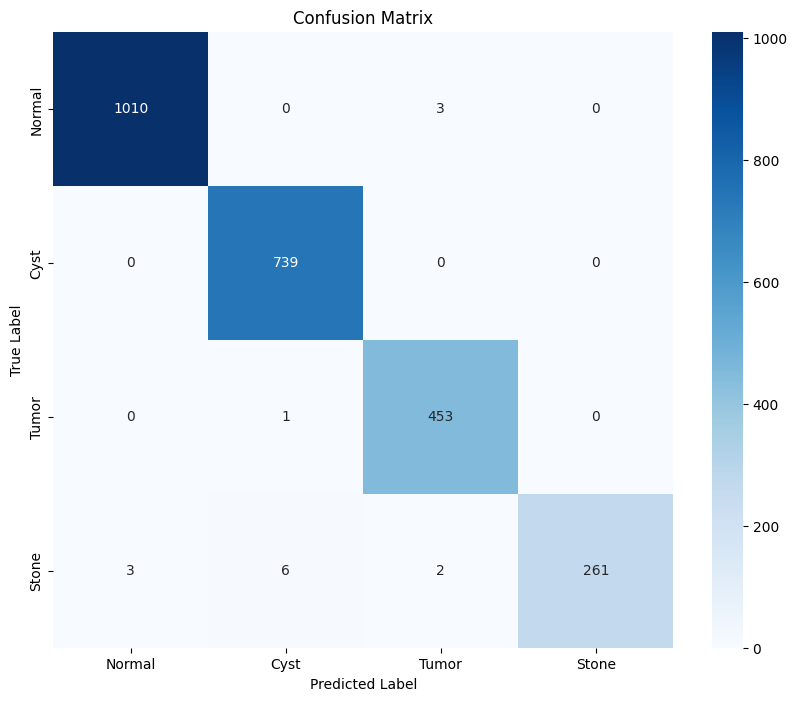


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1013
        Cyst       0.99      1.00      1.00       739
       Tumor       0.99      1.00      0.99       454
       Stone       1.00      0.96      0.98       272

    accuracy                           0.99      2478
   macro avg       0.99      0.99      0.99      2478
weighted avg       0.99      0.99      0.99      2478



In [ ]:

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=full_dataset.classes))

## 8. Save Full Model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'class_to_idx': full_dataset.class_to_idx
}, 'complete_3d_ct_model.pth')